In [4]:
import sys
import os
os.chdir("/home/felixpersson/MasterThesisProject")
print(os.getcwd())

/home/felixpersson/MasterThesisProject


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import json

from models.neutronics.axial_neutron_model import NeutronicsModel
import data.dataclass as d_class

%config InlineBackend.figure_format = "retina"

Mesh warning: N_Z changed from 50 to 46
Mesh warning: Neutronics N_Z changed from 50 to 30
Mesh warning: N_R changed from 15 to 65


In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl

from utils.solver import Solver

mesh = d_class.NeutronicsMesh(
    N_R = 50,
    N_Z = 100,
    l = 1.8
)
energy = d_class.NeutronicsEnergy(
    N_G = 2,
    power = 1000
)
cfg = d_class.NeutronicsConfig(mesh, energy)

neutronics_model = NeutronicsModel(cfg)

solver = Solver([neutronics_model])
solver.fsolve()

phi_n_g, k = solver.solution      # type: ignore

mpl.rcParams["text.usetex"] = True
mpl.rcParams["font.family"] = "Computer modern"
mpl.rcParams["font.size"] = 22

fig = plt.figure(figsize=(16,9))
ax = fig.add_subplot(111)

colors = plt.cm.viridis(np.linspace(0, 1, 8))[::-1] # type: ignore
ax.grid(alpha=0.4)
for i in range(len(colors)):
    ax.plot(phi_n_g[:, i], color=colors[i], label=i)
ax.legend()
ax.set_yscale("log")
ax.set_title(r"$k_{eff} = $" + f"{k:.2f}")

plt.show()

NameError: name 'Path' is not defined

In [11]:
import numpy as np
from scipy.optimize import root_scalar


def solve_two_group_slab_marshak(
    *,
    Sigma_a1,
    Sigma_a2,
    Sigma_s12,
    Sigma_s21,
    nuSigma_f1,
    nuSigma_f2,
    Sigma_f1,
    Sigma_f2,
    D1,
    D2,
    half_width,
    power_per_area,
    kappa=200.0e6 * 1.602176634e-19,
    k_bounds=(0.1, 5.0),
    n_scan=5000,
    n_points=500,
    positivity_tol=1.0e-10,
):
    """
    Solves the fundamental even-mode solution of the 1D two-group
    homogeneous slab diffusion problem with Marshak boundary conditions.

    The fundamental mode is selected by:
        1. solving all detected roots f(k) = 0 in k_bounds,
        2. rejecting modes with internal sign changes,
        3. selecting the remaining root with the largest k_eff.

    This avoids selecting higher-order eigenmodes with negative flux regions.
    """

    a = half_width

    def characteristic_roots(k):
        F1 = nuSigma_f1 / k
        F2 = nuSigma_f2 / k

        aq = D1 * D2

        bq = (
            D1 * (Sigma_a2 + Sigma_s21)
            + D2 * (Sigma_a1 + Sigma_s12 - F1)
        )

        cq = (
            (Sigma_a1 + Sigma_s12 - F1)
            * (Sigma_a2 + Sigma_s21)
            - Sigma_s12 * (F2 + Sigma_s21)
        )

        discriminant = bq**2 - 4.0 * aq * cq

        if discriminant < 0.0:
            raise ValueError(
                f"Negative discriminant for k={k}: {discriminant}"
            )

        q1 = (-bq + np.sqrt(discriminant)) / (2.0 * aq)
        q2 = (-bq - np.sqrt(discriminant)) / (2.0 * aq)

        q_values = np.array([q1, q2])

        q_positive = q_values[q_values > 0.0]
        q_negative = q_values[q_values < 0.0]

        if len(q_positive) != 1 or len(q_negative) != 1:
            raise ValueError(
                f"Expected one positive and one negative q-root for k={k}, "
                f"but got q1={q1}, q2={q2}."
            )

        mu = np.sqrt(q_positive[0])
        lam = np.sqrt(-q_negative[0])

        return mu, lam

    def mode_ratios(k):
        mu, lam = characteristic_roots(k)

        alpha_mu = Sigma_s12 / (
            D2 * mu**2 + Sigma_a2 + Sigma_s21
        )

        alpha_lam = Sigma_s12 / (
            Sigma_a2 + Sigma_s21 - D2 * lam**2
        )

        return mu, lam, alpha_mu, alpha_lam

    def marshak_terms(k):
        mu, lam, alpha_mu, alpha_lam = mode_ratios(k)

        M1_mu = (
            np.cos(mu * a)
            - 2.0 * D1 * mu * np.sin(mu * a)
        )

        M1_lam = (
            np.cosh(lam * a)
            + 2.0 * D1 * lam * np.sinh(lam * a)
        )

        M2_mu = alpha_mu * (
            np.cos(mu * a)
            - 2.0 * D2 * mu * np.sin(mu * a)
        )

        M2_lam = alpha_lam * (
            np.cosh(lam * a)
            + 2.0 * D2 * lam * np.sinh(lam * a)
        )

        return M1_mu, M1_lam, M2_mu, M2_lam

    def eigenvalue_residual(k):
        try:
            M1_mu, M1_lam, M2_mu, M2_lam = marshak_terms(k)
            return M1_mu * M2_lam - M1_lam * M2_mu
        except Exception:
            return np.nan

    def unnormalised_flux_shape(k):
        mu, lam, alpha_mu, alpha_lam = mode_ratios(k)
        M1_mu, M1_lam, _, _ = marshak_terms(k)

        rho = -M1_mu / M1_lam

        x = np.linspace(-a, a, n_points)

        phi1_shape = (
            np.cos(mu * x)
            + rho * np.cosh(lam * x)
        )

        phi2_shape = (
            alpha_mu * np.cos(mu * x)
            + rho * alpha_lam * np.cosh(lam * x)
        )

        if phi1_shape[n_points // 2] < 0.0:
            phi1_shape *= -1.0
            phi2_shape *= -1.0
            rho *= -1.0

        return x, phi1_shape, phi2_shape, rho

    def is_fundamental_candidate(k):
        try:
            x, phi1_shape, phi2_shape, rho = unnormalised_flux_shape(k)
            mu, lam, alpha_mu, alpha_lam = mode_ratios(k)

            phi1_min = np.min(phi1_shape)
            phi2_min = np.min(phi2_shape)

            no_negative_flux = (
                phi1_min >= -positivity_tol * np.max(np.abs(phi1_shape))
                and phi2_min >= -positivity_tol * np.max(np.abs(phi2_shape))
            )

            no_internal_nodes = (
                not np.any(np.diff(np.signbit(phi1_shape)))
                and not np.any(np.diff(np.signbit(phi2_shape)))
            )

            return no_negative_flux and no_internal_nodes

        except Exception:
            return False

    def find_all_roots():
        k_min, k_max = k_bounds
        k_values = np.linspace(k_min, k_max, n_scan)
        f_values = np.array([eigenvalue_residual(k) for k in k_values])

        valid = np.isfinite(f_values)
        k_values = k_values[valid]
        f_values = f_values[valid]

        roots = []

        for i in range(len(k_values) - 1):
            k_left = k_values[i]
            k_right = k_values[i + 1]
            f_left = f_values[i]
            f_right = f_values[i + 1]

            if f_left == 0.0:
                roots.append(k_left)
                continue

            if f_left * f_right < 0.0:
                sol = root_scalar(
                    eigenvalue_residual,
                    bracket=(k_left, k_right),
                    method="brentq",
                    xtol=1e-12,
                    rtol=1e-10,
                )

                if sol.converged:
                    roots.append(sol.root)

        roots = np.array(roots)

        if len(roots) == 0:
            raise RuntimeError(
                "No roots of f(k) were found. Try widening k_bounds "
                "or increasing n_scan."
            )

        roots = np.unique(np.round(roots, decimals=10))

        return roots

    roots = find_all_roots()

    admissible_roots = [
        k for k in roots
        if is_fundamental_candidate(k)
    ]

    if len(admissible_roots) == 0:
        raise RuntimeError(
            "Roots were found, but none produced a non-negative, node-free "
            "fundamental flux shape. Try widening k_bounds, increasing n_scan, "
            "or check the cross-section data."
        )

    k_eff = max(admissible_roots)

    mu, lam, alpha_mu, alpha_lam = mode_ratios(k_eff)
    M1_mu, M1_lam, M2_mu, M2_lam = marshak_terms(k_eff)

    rho = -M1_mu / M1_lam

    x = np.linspace(-a, a, n_points)

    phi1_shape = (
        np.cos(mu * x)
        + rho * np.cosh(lam * x)
    )

    phi2_shape = (
        alpha_mu * np.cos(mu * x)
        + rho * alpha_lam * np.cosh(lam * x)
    )

    if phi1_shape[n_points // 2] < 0.0:
        phi1_shape *= -1.0
        phi2_shape *= -1.0
        rho *= -1.0

    denominator = np.trapezoid(
        kappa * (
            Sigma_f1 * phi1_shape
            + Sigma_f2 * phi2_shape
        ),
        x,
    )

    A = power_per_area / denominator
    C = rho * A

    phi1 = A * phi1_shape
    phi2 = A * phi2_shape

    return {
        "k_eff": k_eff,
        "mu": mu,
        "lambda": lam,
        "alpha_mu": alpha_mu,
        "alpha_lambda": alpha_lam,
        "rho": rho,
        "A": A,
        "C": C,
        "x": x,
        "phi1": phi1,
        "phi2": phi2,
        "all_roots": roots,
        "admissible_roots": admissible_roots,
        "residual": eigenvalue_residual(k_eff),
    }

In [12]:
result = solve_two_group_slab_marshak(
    Sigma_a1=0.01,
    Sigma_a2=0.08,
    Sigma_s12=0.04,
    Sigma_s21=0.0,
    nuSigma_f1=0.005,
    nuSigma_f2=0.12,
    Sigma_f1=0.002,
    Sigma_f2=0.05,
    D1=1.2,
    D2=0.35,
    half_width=100.0,
    power_per_area=1.0e6,
    k_bounds=(0.1, 5.0),
)

print(result["k_eff"])
print(result["A"], result["C"])

1.2914106922
8913920433783237.0 1.6020450096854304e-09


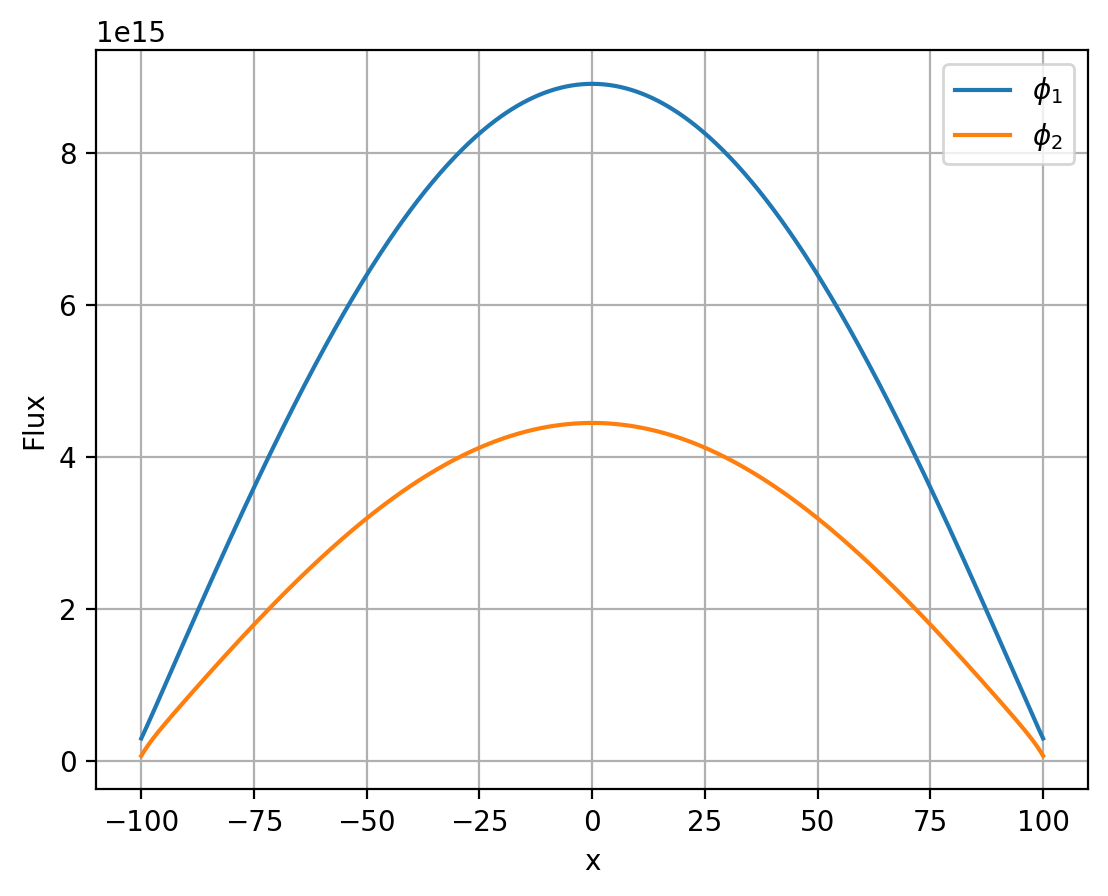

In [13]:
x = result["x"]

plt.figure()
plt.plot(x, result["phi1"], label=r"$\phi_1$")
plt.plot(x, result["phi2"], label=r"$\phi_2$")
plt.xlabel("x")
plt.ylabel("Flux")
plt.legend()
plt.grid(True)
plt.show()